In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [2]:
# Read the image
img = cv2.imread("/Users/vanshilpatel/Desktop/pdeu/cv pdeu/exp4/Image.png", cv2.IMREAD_GRAYSCALE)

In [3]:
# Adding some random noise
mean_value = 0
noise_sigma = 60

In [4]:
random_noise = np.random.normal(
    mean_value,
    noise_sigma,
    img.shape
)

noisy_img = img.astype(np.float32) + random_noise

noisy_img = np.clip(noisy_img, 0, 255)
noisy_img = noisy_img.astype(np.uint8)


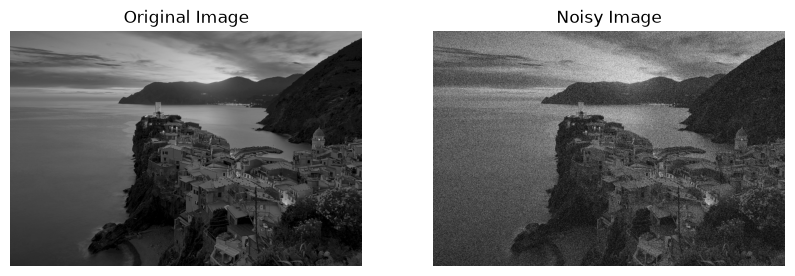

In [5]:
# Show original and noisy image
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(noisy_img, cmap="gray")
plt.title("Noisy Image")
plt.axis("off")

plt.show()

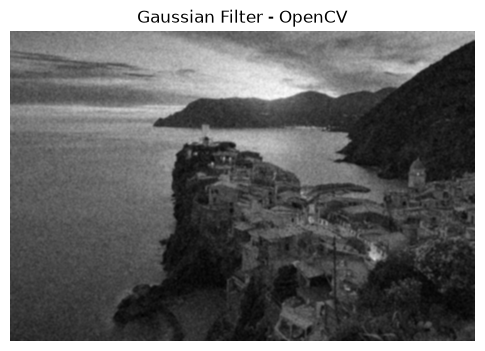

In [6]:
# Gaussian filter using OpenCV
opencv_result = cv2.GaussianBlur(
    noisy_img,
    (15, 15),
    5
)

plt.figure(figsize=(6, 6))
plt.imshow(opencv_result, cmap="gray")
plt.title("Gaussian Filter - OpenCV")
plt.axis("off")
plt.show()

In [7]:
# Our own Gaussian filter
def my_gaussian_filter(img, size=15, sigma=5):

    half = size // 2

    # Making the Gaussian kernel
    x, y = np.mgrid[-half:half+1, -half:half+1]

    gaussian = np.exp(
        -(x**2 + y**2) / (2 * sigma**2)
    )

    gaussian = gaussian / np.sum(gaussian)

    # Add padding around image
    padded_img = np.pad(
        img,
        ((half, half), (half, half)),
        mode="edge"
    )

    height, width = img.shape

    result = np.zeros(
        (height, width),
        dtype=np.float32
    )

    # Applying the filter
    for row in range(height):
        for col in range(width):

            small_part = padded_img[
                row:row + size,
                col:col + size
            ]

            result[row, col] = np.sum(
                small_part * gaussian
            )

    result = np.clip(result, 0, 255)

    return result.astype(np.uint8)


my_result = my_gaussian_filter(
    noisy_img,
    size=15,
    sigma=5
)

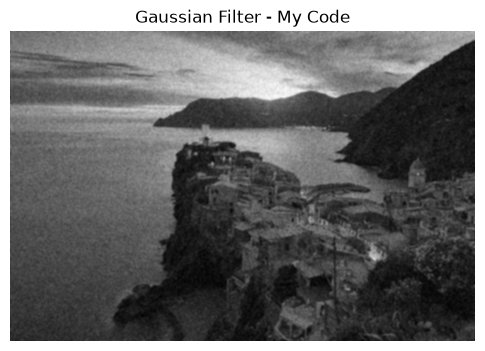

In [8]:
# Display our result
plt.figure(figsize=(6, 6))

plt.imshow(my_result, cmap="gray")
plt.title("Gaussian Filter - My Code")
plt.axis("off")

plt.show()

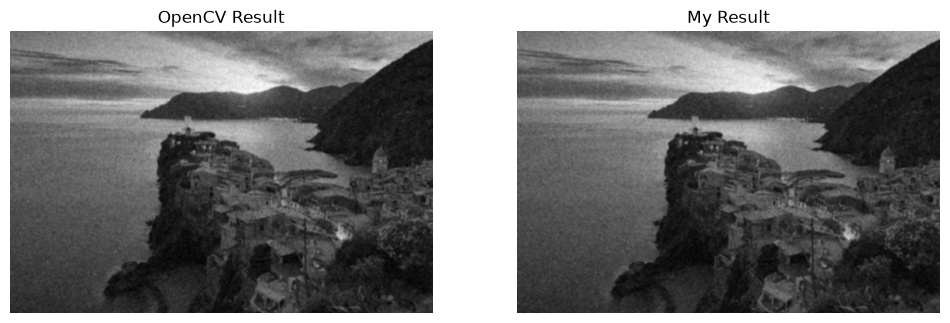

In [9]:
# Compare both results
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(opencv_result, cmap="gray")
plt.title("OpenCV Result")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(my_result, cmap="gray")
plt.title("My Result")
plt.axis("off")

plt.show()

In [10]:
# Checking image sizes
print("Original image size:", img.shape)
print("Noisy image size:", noisy_img.shape)
print("Filtered image size:", my_result.shape)

Original image size: (1600, 2400)
Noisy image size: (1600, 2400)
Filtered image size: (1600, 2400)
